This project analyzes Tesla’s production and delivery performance from 2015–2025 using Python, Pandas, Matplotlib and Seaborn. The objective is to identify business trends, regional performance and correlations between production-related factors.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nStatistical Summary:")
display(df.describe())

Shape of dataset: (2640, 12)

Columns:
 Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
print("Regions:")
print(df['Region'].unique())

print("\nModels:")
print(df['Model'].unique())

print("\nSource Types:")
print(df['Source_Type'].unique())

Regions:
['Europe' 'Asia' 'North America' 'Middle East']

Models:
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

Source Types:
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


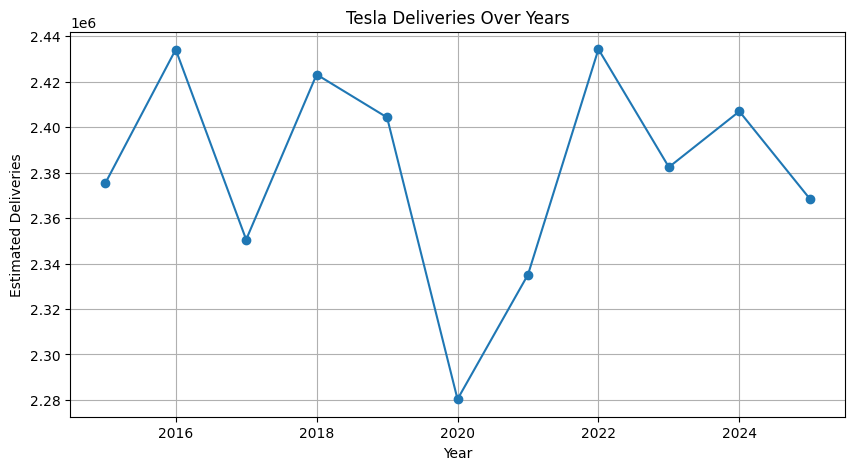

In [9]:
import matplotlib.pyplot as plt

yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_deliveries.index, yearly_deliveries.values, marker='o')

plt.title("Tesla Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)
plt.show()

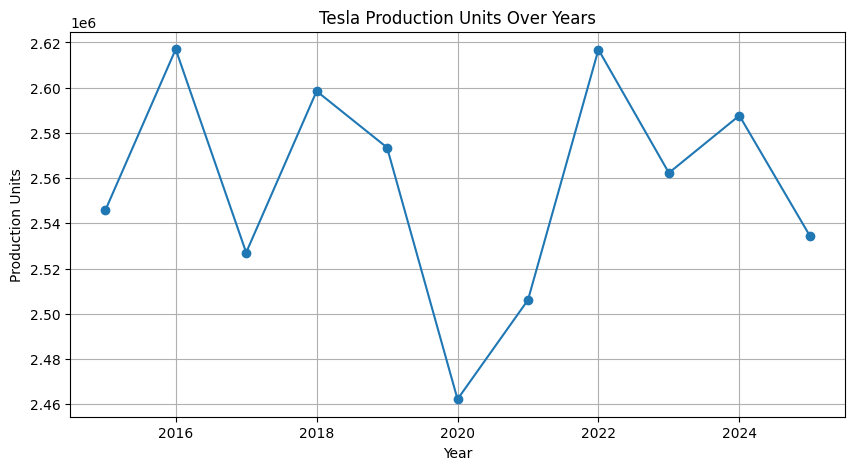

In [10]:
yearly_production = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_production.index, yearly_production.values, marker='o')

plt.title("Tesla Production Units Over Years")
plt.xlabel("Year")
plt.ylabel("Production Units")

plt.grid(True)
plt.show()

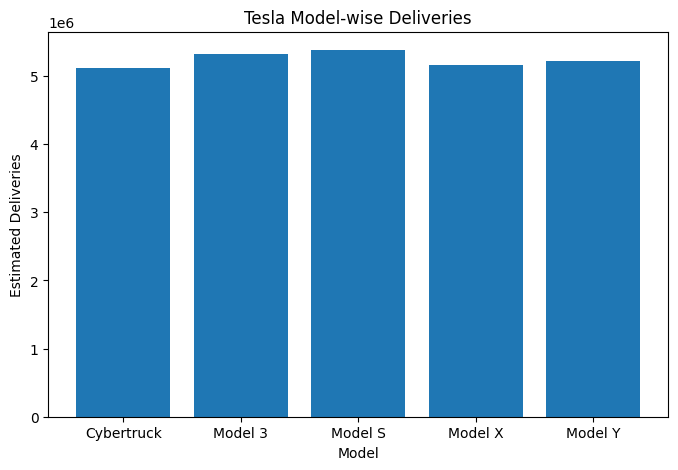

In [11]:
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))
plt.bar(model_sales.index, model_sales.values)

plt.title("Tesla Model-wise Deliveries")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")

plt.show()

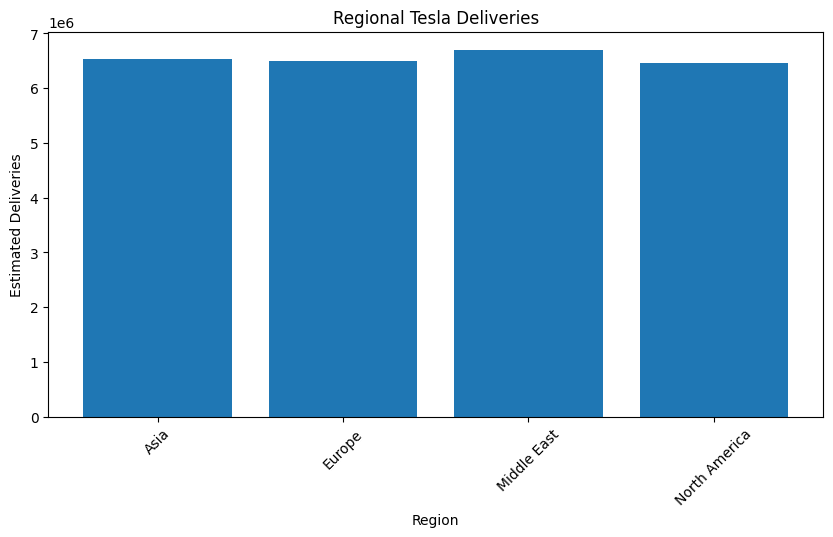

In [12]:
region_sales = df.groupby('Region')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
plt.bar(region_sales.index, region_sales.values)

plt.title("Regional Tesla Deliveries")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")

plt.xticks(rotation=45)

plt.show()

In [13]:
correlation = df.corr(numeric_only=True)

print(correlation)

                              Year         Month  Estimated_Deliveries  \
Year                  1.000000e+00  2.216119e-15             -0.002863   
Month                 2.216119e-15  1.000000e+00              0.030877   
Estimated_Deliveries -2.863112e-03  3.087690e-02              1.000000   
Production_Units     -2.760884e-03  2.897149e-02              0.994234   
Avg_Price_USD        -4.990980e-03  2.485676e-02             -0.027546   
Battery_Capacity_kWh -3.048584e-02  1.714479e-03             -0.007765   
Range_km             -2.912765e-02  2.142889e-03             -0.006606   
CO2_Saved_tons       -1.924402e-02  3.291988e-02              0.836814   
Charging_Stations    -3.465622e-03 -1.132526e-02              0.000753   

                      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  \
Year                         -0.002761      -0.004991             -0.030486   
Month                         0.028971       0.024857              0.001714   
Estimated_Deliveries  

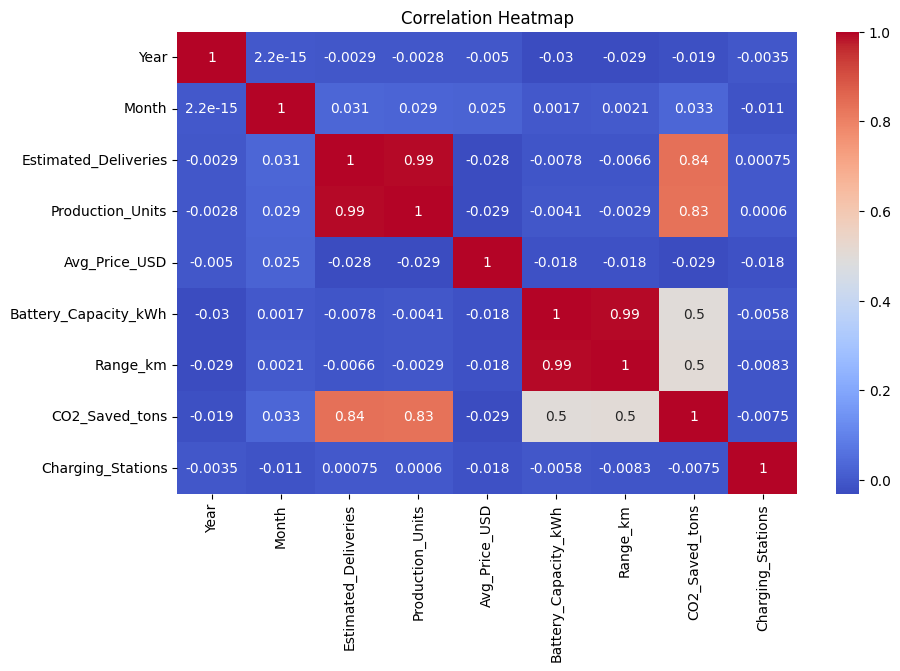

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Key Insights:

1. Tesla deliveries and production increased significantly over the years.

2. Certain Tesla models contributed more heavily to total deliveries.

3. North America and Europe showed strong delivery performance.

4. Battery capacity and driving range positively influenced vehicle demand.

5. Expansion of charging stations supported Tesla’s global growth.

6. Strong correlation exists between production units and estimated deliveries.

Conclusion:

This analysis explored Tesla’s production, deliveries, pricing, battery capacity and regional performance from 2015–2025. The results show strong global growth in Tesla’s EV market, increasing production efficiency and expansion of charging infrastructure. Data visualization and correlation analysis helped identify important business and technological trends.